In [63]:
import pandas as pd
import plotly.express as px
from sklearn.linear_model import LinearRegression
import numpy as np
import plotly.graph_objects as go

# Analisis de los datos de suministro diario de agua por entidad federativa

In [64]:
suministroAgua2008_2010=pd.read_csv('../data/SuministroDiarioDeAguaConeval/SIDS_AE Vi-1 RESULTADOS.csv',encoding='latin-1',usecols=[0,1], skiprows=1)
suministroAgua2012_2014=pd.read_csv('../data/SuministroDiarioDeAguaConeval/SIDS_AE Vi-1 RESULTADOS (1).csv',encoding='latin-1',usecols=[1,2],skiprows=1)
suministroAgua2016_2018=pd.read_csv('../data/SuministroDiarioDeAguaConeval/SIDS_AE Vi-1 RESULTADOS (2).csv',encoding='latin-1',usecols=[1,2],skiprows=1)
suministroAgua2020_2022=pd.read_csv('../data/SuministroDiarioDeAguaConeval/SIDS_AE Vi-1 RESULTADOS (3).csv',encoding='latin-1',usecols=[1,2],skiprows=1)

suministro_total = pd.concat([
    suministroAgua2008_2010.reset_index(drop=True),
    suministroAgua2012_2014.reset_index(drop=True),
    suministroAgua2016_2018.reset_index(drop=True),
    suministroAgua2020_2022.reset_index(drop=True)
], axis=1)
suministro_total=suministro_total.drop([33,34,35,36,37])
suministro_total

,Entidad,2008,2012,2014,2016,2018,2020,2022
0,Aguascalientes,90.259341,87.973873,83.612526,88.228302,87.795055,82.501699,79.870160
1,Baja California,88.733682,88.263897,81.311992,86.310814,84.086361,87.577967,89.402182
2,Baja California Sur,44.190183,50.519383,25.980949,23.386389,19.040462,17.227671,21.188654
3,Campeche,41.914509,49.961139,45.026233,54.655881,50.739647,55.022463,47.460569
4,Coahuila,70.192819,64.465088,70.156050,69.042698,73.363477,75.764865,71.723230
5,Colima,86.041098,83.917917,83.846406,83.152164,81.308398,82.820804,81.765944
6,Chiapas,14.404374,15.251299,10.947973,9.246656,12.549663,14.375526,10.550023
7,Chihuahua,83.736222,86.994873,85.968306,87.299295,89.352344,88.180311,90.999942
8,Ciudad de México,72.097164,69.666024,73.618802,70.538816,67.747348,73.543868,72.299000
9,Durango,64.771339,61.941139,72.952830,72.862592,72.793644,75.609462,71.238343


Datos transformados:
               Entidad   Año  Porcentaje
0       Aguascalientes  2008   90.259341
1      Baja California  2008   88.733682
2  Baja California Sur  2008   44.190183
3             Campeche  2008   41.914509
4             Coahuila  2008   70.192819

Años disponibles: [np.int64(2008), np.int64(2012), np.int64(2014), np.int64(2016), np.int64(2018), np.int64(2020), np.int64(2022)]
Entidades: 33


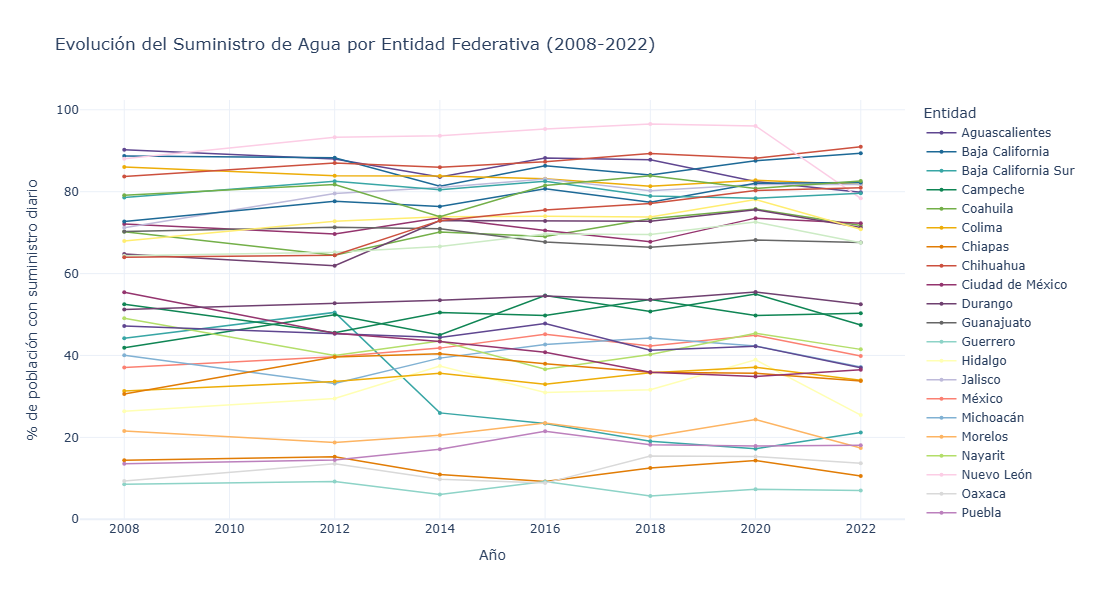

In [65]:
colores = px.colors.qualitative.Prism + px.colors.qualitative.Set3
df_tidy = pd.melt(
    suministro_total,  
    id_vars=['Entidad'],
    var_name='Año', 
    value_name='Porcentaje'
)
df_tidy['Año'] = df_tidy['Año'].astype(int)

print("Datos transformados:")
print(df_tidy.head())
print(f"\nAños disponibles: {sorted(df_tidy['Año'].unique())}")
print(f"Entidades: {df_tidy['Entidad'].nunique()}")


fig = px.line(
    df_tidy, 
    x='Año', 
    y='Porcentaje', 
    color='Entidad',
    color_discrete_sequence=colores,
    title='Evolución del Suministro de Agua por Entidad Federativa (2008-2022)',
    labels={'Porcentaje': '% de población con suministro diario', 'Año': 'Año'},
    template='plotly_white'
)


fig.update_traces(mode='lines+markers', marker=dict(size=4), line=dict(width=1.5))
fig.update_layout(
    height=600,
    hovermode='x unified',
    legend=dict(
        title='Entidad',
        orientation='v',
        yanchor='top',
        y=1,
        xanchor='left',
        x=1.02
    )
)


fig.show()


fig.write_html('grafica_suministro_agua.html')

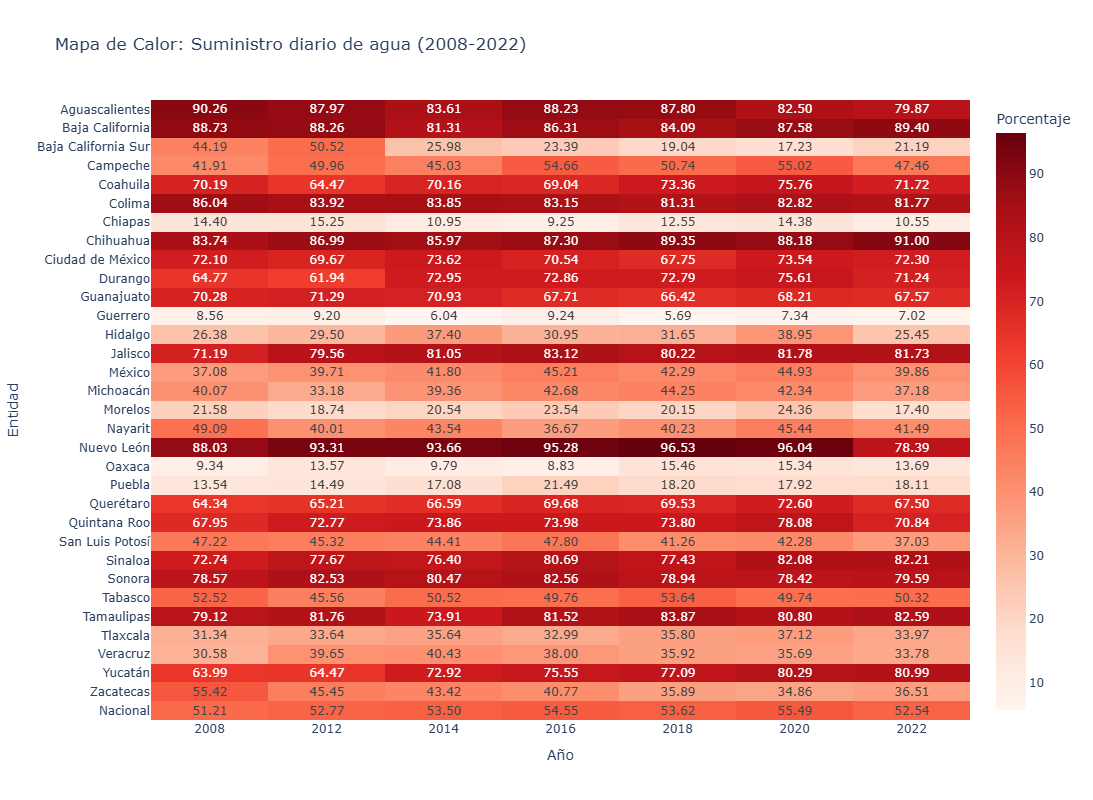

In [66]:
matriz = suministro_total.set_index('Entidad')
fig = px.imshow(
    matriz,
    text_auto='.2f',
    aspect='auto',
    title='Mapa de Calor: Suministro diario de agua (2008-2022)',
    labels=dict(x='Año', y='Entidad', color='Porcentaje'),
    color_continuous_scale='Reds',
    template='plotly_white'
)
fig.write_html('mapa_calor_suministro_diario_agua.html')
fig.update_layout(height=800)
fig.show()

# Visualizacion y analisis de los datos del porcentaje del servicio de agua entubada por entidad federativa

In [67]:
servicioAguaEntubada = pd.read_excel(
    '../data/ServicioAguaEntubada/d1_siscds03_01.xlsx',
    skiprows=2,
    header=0
)
servicioAguaEntubada=servicioAguaEntubada.drop(0)
if servicioAguaEntubada.columns[0] != 'Entidad':
    servicioAguaEntubada.rename(columns={servicioAguaEntubada.columns[0]: 'Entidad'}, inplace=True)
servicioAguaEntubada

,Entidad,1990,1995,2000,2005,2010,2015,2020
1,Aguascalientes,95.49,97.97,97.89,97.79,98.84,99.14,99.33
2,Baja California,79.76,86.75,91.94,93.84,95.87,97.13,97.68
3,Baja California Sur,89.37,90.86,92.53,87.69,92.56,92.70,94.14
4,Campeche,69.85,78.28,84.68,88.35,89.99,93.49,95.57
5,Coahuila,91.92,94.59,97.02,97.34,98.32,98.20,98.86
6,Colima,93.03,95.82,97.12,97.79,98.57,98.98,99.07
7,Chiapas,57.27,65.55,73.54,73.50,77.29,86.46,88.87
8,Chihuahua,87.57,91.79,93.07,92.86,94.57,95.73,98.13
9,Ciudad de México,96.13,97.74,97.85,97.58,97.67,98.58,98.65
10,Durango,84.60,89.58,91.65,90.91,93.87,96.67,97.50


Datos transformados:
               Entidad   Año  Porcentaje
0       Aguascalientes  1990       95.49
1      Baja California  1990       79.76
2  Baja California Sur  1990       89.37
3             Campeche  1990       69.85
4             Coahuila  1990       91.92

Años disponibles: [np.int64(1990), np.int64(1995), np.int64(2000), np.int64(2005), np.int64(2010), np.int64(2015), np.int64(2020)]
Entidades: 33


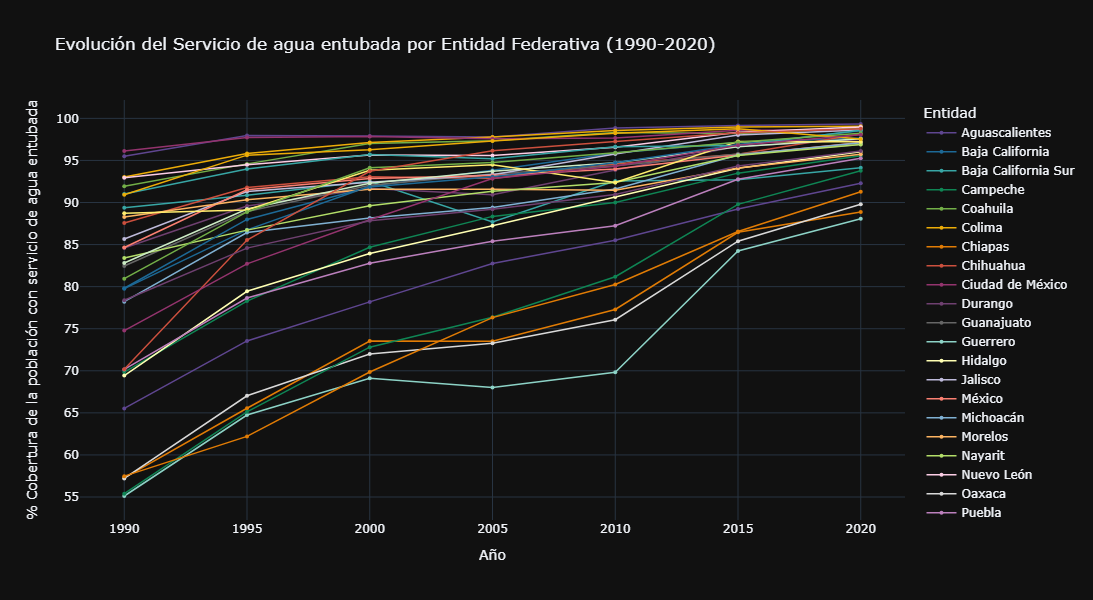

In [68]:
columna_entidad = servicioAguaEntubada.columns[0]  
colores = px.colors.qualitative.Prism + px.colors.qualitative.Set3
df_tidy = pd.melt(
    servicioAguaEntubada,  
    id_vars=[columna_entidad],
    var_name='Año', 
    value_name='Porcentaje'
)
df_tidy['Año'] = df_tidy['Año'].astype(int)

print("Datos transformados:")
print(df_tidy.head())
print(f"\nAños disponibles: {sorted(df_tidy['Año'].unique())}")
print(f"Entidades: {df_tidy['Entidad'].nunique()}")

fig = px.line(
    df_tidy, 
    x='Año', 
    y='Porcentaje', 
    color='Entidad',
    color_discrete_sequence=colores,
    title='Evolución del Servicio de agua entubada por Entidad Federativa (1990-2020)',
    labels={'Porcentaje': '% Cobertura de la población con servicio de agua entubada', 'Año': 'Año'},
    template='plotly_dark'
)

fig.update_traces(mode='lines+markers', marker=dict(size=4), line=dict(width=1.5))
fig.update_layout(
    height=600,
    hovermode='x unified',
    legend=dict(
        title='Entidad',
        orientation='v',
        yanchor='top',
        y=1,
        xanchor='left',
        x=1.02
    )
)

fig.show()

fig.write_html('grafica_servicio_agua_entubada.html')

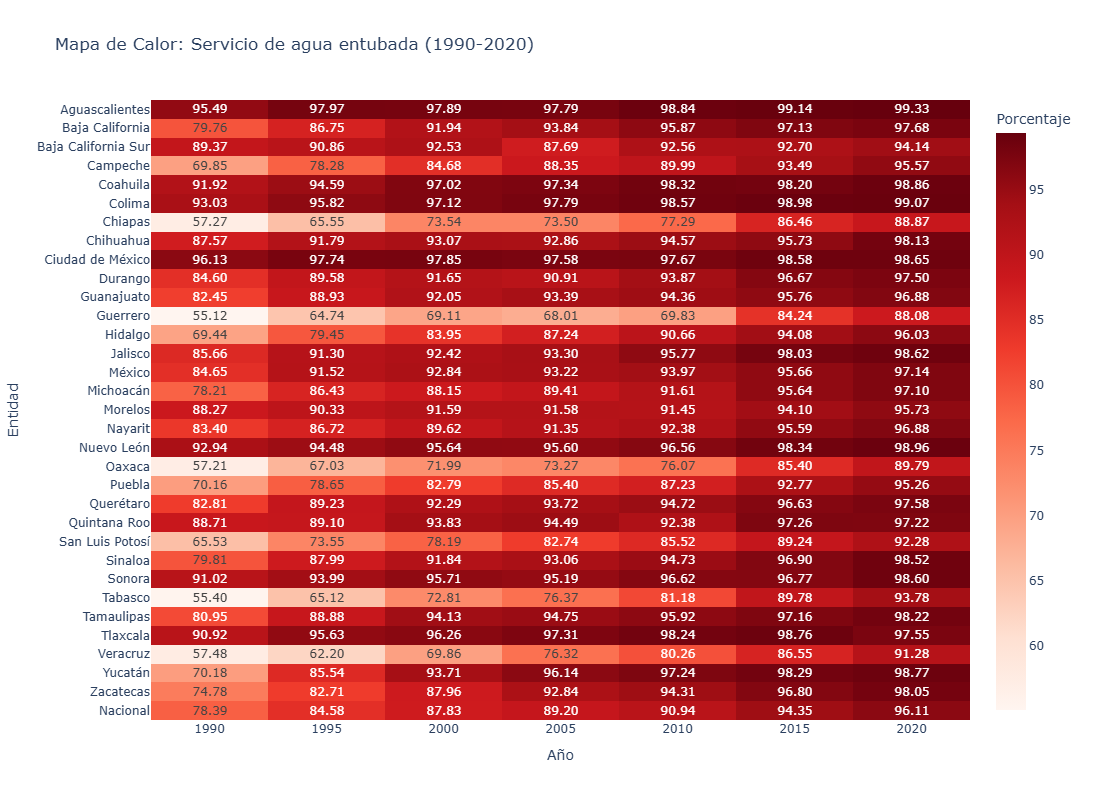

In [69]:
matriz = servicioAguaEntubada.set_index('Entidad')
fig = px.imshow(
    matriz,
    text_auto='.2f',
    aspect='auto',
    title='Mapa de Calor: Servicio de agua entubada (1990-2020)',
    labels=dict(x='Año', y='Entidad', color='Porcentaje'),
    color_continuous_scale='Reds',
    template='plotly_white'
)
fig.update_layout(height=800)
fig.write_html('mapa_calor_servicio_agua_entubada.html')
fig.show()

# Visualizacion y analisis de los datos del porcentaje del indice de rezago social por entidad federativa¶

In [71]:
indiceDeRezagoSocial2000 = pd.read_excel(
    '../data/IndiceDeRezagoSocial/IRS_entidades_mpios_2000.xlsx',
    usecols=['Entidad federativa','Índice de rezago social'],
    skiprows=4,
    header=0
)

indiceDeRezagoSocial2005 = pd.read_excel(
    '../data/IndiceDeRezagoSocial/IRS_entidades_mpios_2005.xlsx',
    usecols=['Índice de rezago social'],
    skiprows=4,
    header=0
)
indiceDeRezagoSocial2010 = pd.read_excel(
    '../data/IndiceDeRezagoSocial/IRS_entidades_mpios_2010.xlsx',
    usecols=['Índice de rezago social'],
    skiprows=4,
    header=0
)
indiceDeRezagoSocial2015 = pd.read_excel(
    '../data/IndiceDeRezagoSocial/IRS_entidades_mpios_2015.xlsx',
    usecols=['Índice de rezago social'],
    skiprows=4,
    header=0
)
indiceDeRezagoSocial2020 = pd.read_excel(
    '../data/IndiceDeRezagoSocial/IRS_entidades_mpios_2020.xlsx',
    usecols=['Índice de rezago social'],
    skiprows=4,
    header=0
)

indiceDeRezagoSocial2000_2020=pd.concat([
    indiceDeRezagoSocial2000.reset_index(drop=True),
    indiceDeRezagoSocial2005.reset_index(drop=True),
    indiceDeRezagoSocial2010.reset_index(drop=True),
    indiceDeRezagoSocial2015.reset_index(drop=True),
    indiceDeRezagoSocial2020.reset_index(drop=True)
], axis=1)
indiceDeRezagoSocial2000_2020=indiceDeRezagoSocial2000_2020.drop([0,1,34,35,36,37,38])
indiceDeRezagoSocial2000_2020.columns = ['Entidad', '2000', '2005', '2010', '2015', '2020']
indiceDeRezagoSocial2000_2020

,Entidad,2000,2005,2010,2015,2020
2,Aguascalientes,-1.135999,-1.144505,-1.106007,-1.036695,-1.101561
3,Baja California,-1.028277,-0.663637,-0.855111,-0.818078,-0.642387
4,Baja California Sur,-0.710752,-0.481994,-0.473796,-0.395355,-0.317027
5,Campeche,0.534566,0.324935,0.216209,0.304117,0.244535
6,Coahuila,-1.266207,-1.250579,-1.160584,-1.064973,-1.147587
7,Colima,-0.708163,-0.756951,-0.803184,-0.657650,-0.690655
8,Chiapas,2.267370,2.548142,2.271180,2.387669,2.644224
9,Chihuahua,-0.738870,-0.606449,-0.499152,-0.587185,-0.518357
10,Distrito Federal,-1.509716,-1.396498,-1.283248,-1.313332,-1.115345
11,Durango,-0.142996,-0.241208,-0.008311,-0.032549,-0.045956


Datos transformados:
               Entidad   Año  Porcentaje
0       Aguascalientes  2000   -1.135999
1      Baja California  2000   -1.028277
2  Baja California Sur  2000   -0.710752
3             Campeche  2000    0.534566
4             Coahuila  2000   -1.266207

Años disponibles: [np.int64(2000), np.int64(2005), np.int64(2010), np.int64(2015), np.int64(2020)]
Entidades: 32


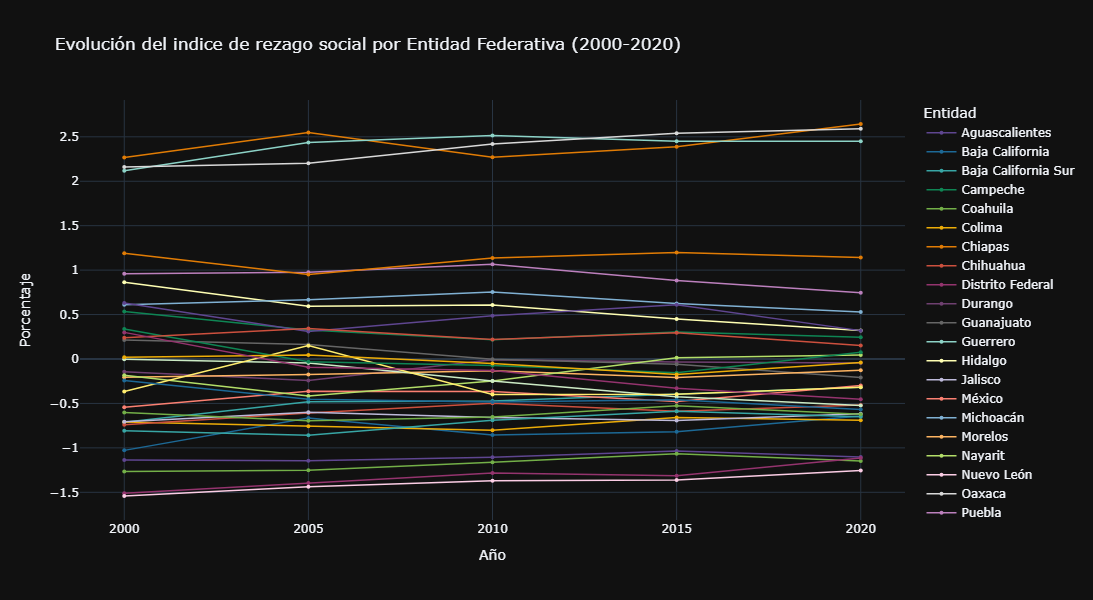

In [72]:
columna_entidad = indiceDeRezagoSocial2000_2020.columns[0]  
colores = px.colors.qualitative.Prism + px.colors.qualitative.Set3
df_tidy = pd.melt(
    indiceDeRezagoSocial2000_2020,  
    id_vars=[columna_entidad],
    var_name='Año', 
    value_name='Porcentaje'
)
df_tidy['Año'] = df_tidy['Año'].astype(int)

# Verificar que funcionó
print("Datos transformados:")
print(df_tidy.head())
print(f"\nAños disponibles: {sorted(df_tidy['Año'].unique())}")
print(f"Entidades: {df_tidy['Entidad'].nunique()}")

fig = px.line(
    df_tidy, 
    x='Año', 
    y='Porcentaje', 
    color='Entidad',
    color_discrete_sequence=colores,
    title='Evolución del indice de rezago social por Entidad Federativa (2000-2020)',
    labels={'Indice': 'Indice de rezago social', 'Año': 'Año'},
    template='plotly_dark'
)

fig.update_traces(mode='lines+markers', marker=dict(size=4), line=dict(width=1.5))
fig.update_layout(
    height=600,
    hovermode='x unified',
    legend=dict(
        title='Entidad',
        orientation='v',
        yanchor='top',
        y=1,
        xanchor='left',
        x=1.02
    )
)

fig.show()

fig.write_html('indice_de_rezago_social.html')

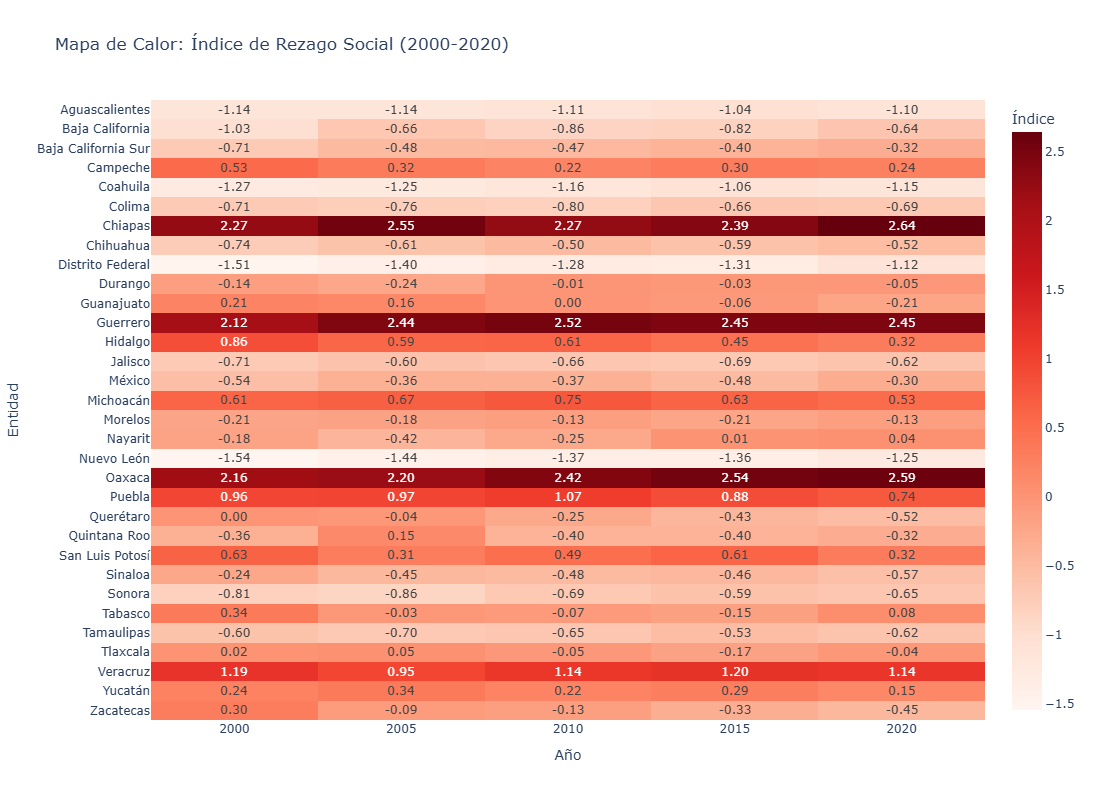

In [73]:
matriz = indiceDeRezagoSocial2000_2020.set_index('Entidad')
fig = px.imshow(
    matriz,
    text_auto='.2f',
    aspect='auto',
    title='Mapa de Calor: Índice de Rezago Social (2000-2020)',
    labels=dict(x='Año', y='Entidad', color='Índice'),
    color_continuous_scale='Reds',
    template='plotly_white'
)
fig.update_layout(height=800)
fig.write_html('mapa_calor_rezago_social.html')
fig.show()

# Propuesta de la solucion tomando datos anteriores

## Limpieza de los datos y se tomaran los datos del año 2020

In [74]:
suministroAgua2020_2022=pd.read_csv('../data/SuministroDiarioDeAguaConeval/SIDS_AE Vi-1 RESULTADOS (3).csv',encoding='latin-1',usecols=[0,1],skiprows=1)
suministroAgua2020_2022=suministroAgua2020_2022.reset_index(drop=True)
suministroAgua2020_2022=suministroAgua2020_2022.drop([33,34,35,36,32])
suministroAgua2020_2022.columns.values[1] = 'Porcentaje de suministro diario'
suministroAgua2020_2022

,Entidad,Porcentaje de suministro diario
0,Aguascalientes,82.501699
1,Baja California,87.577967
2,Baja California Sur,17.227671
3,Campeche,55.022463
4,Coahuila,75.764865
5,Colima,82.820804
6,Chiapas,14.375526
7,Chihuahua,88.180311
8,Ciudad de México,73.543868
9,Durango,75.609462


In [75]:
indiceDeRezagoSocial2020 = pd.read_excel(
    '../data/IndiceDeRezagoSocial/IRS_entidades_mpios_2020.xlsx',
    usecols=['Índice de rezago social'],
    skiprows=4,
    header=0
)
indiceDeRezagoSocial2020=indiceDeRezagoSocial2020.drop([0,1,34,35,36,37,38])
indiceDeRezagoSocial2020

,Índice de rezago social
2,-1.101561
3,-0.642387
4,-0.317027
5,0.244535
6,-1.147587
7,-0.690655
8,2.644224
9,-0.518357
10,-1.115345
11,-0.045956


## Union de los datos anterior para su comparacion

In [76]:
suministro_vs_rezagoSocial = pd.concat([
     suministroAgua2020_2022.reset_index(drop=True),
    indiceDeRezagoSocial2020.reset_index(drop=True)
   
], axis=1)
suministro_vs_rezagoSocial

,Entidad,Porcentaje de suministro diario,Índice de rezago social
0,Aguascalientes,82.501699,-1.101561
1,Baja California,87.577967,-0.642387
2,Baja California Sur,17.227671,-0.317027
3,Campeche,55.022463,0.244535
4,Coahuila,75.764865,-1.147587
5,Colima,82.820804,-0.690655
6,Chiapas,14.375526,2.644224
7,Chihuahua,88.180311,-0.518357
8,Ciudad de México,73.543868,-1.115345
9,Durango,75.609462,-0.045956


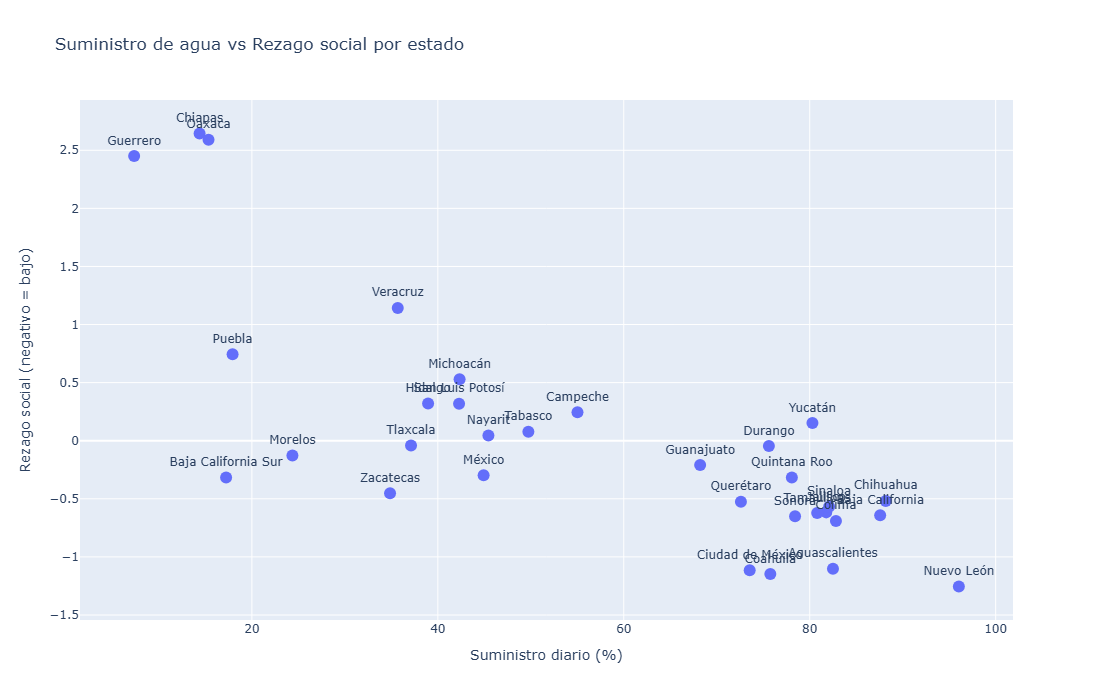

In [77]:
fig = px.scatter(
    suministro_vs_rezagoSocial,
    y='Índice de rezago social',
    x='Porcentaje de suministro diario',
    text='Entidad',          # muestra el nombre del estado sobre el punto
    hover_name='Entidad',    # al pasar el mouse también sale el nombre
    title='Suministro de agua vs Rezago social por estado',
    labels={
        'Índice de rezago social': 'Rezago social (negativo = bajo)',
        'Porcentaje de suministro diario': 'Suministro diario (%)'
    }
)

fig.update_traces(textposition='top center', marker=dict(size=12))
fig.update_layout(width=1000, height=700)  
fig.show()

Conclusiones sobre la relación entre suministro de agua y rezago social Con los datos reales (los primeros que me mostraste, donde Chihuahua tiene 88% y Guerrero 7%), se observa una clara tendencia: los estados con mayor rezago social, como Chiapas y Guerrero, presentan los porcentajes de suministro diario de agua más bajos. En cambio, entidades con rezago social negativo (bajo rezago), como Coahuila, Aguascalientes y Chihuahua, alcanzan suministros superiores al 75%. Esta relación inversa sugiere que la desigualdad social está asociada a un menor acceso al agua potable.

Sin embargo, existen excepciones que enriquecen el análisis. Baja California Sur, a pesar de tener un rezago social bajo (-0.32), registra solo un 17% de suministro. Esto indica que factores geográficos y climáticos (la aridez de la región) pueden limitar el acceso al agua independientemente del nivel de desarrollo social. Por otro lado, la Ciudad de México, con un rezago bajo (-1.11), alcanza un 73.5% de suministro, mostrando que una buena infraestructura puede compensar la escasez natural.

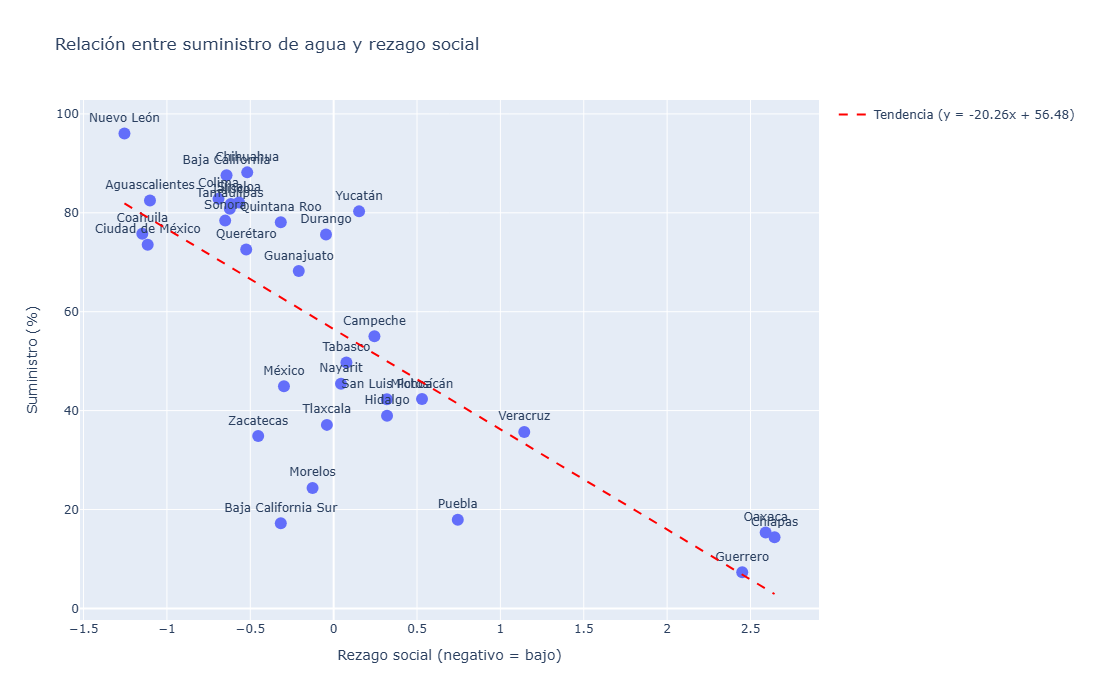

In [78]:
fig = px.scatter(suministro_vs_rezagoSocial, x='Índice de rezago social', y='Porcentaje de suministro diario',
                 text='Entidad', hover_name='Entidad',
                 title='Relación entre suministro de agua y rezago social',
                 labels={'Índice de rezago social': 'Rezago social (negativo = bajo)',
                         'Porcentaje de suministro diario': 'Suministro (%)'},
                 width=900, height=600)
fig.update_traces(textposition='top center', marker=dict(size=12))

X = suministro_vs_rezagoSocial[['Índice de rezago social']].values
y = suministro_vs_rezagoSocial['Porcentaje de suministro diario'].values
model = LinearRegression()
model.fit(X, y)
x_line = np.linspace(X.min(), X.max(), 100)
y_line = model.predict(x_line.reshape(-1, 1))

fig.add_trace(go.Scatter(x=x_line, y=y_line, mode='lines',
                         name=f'Tendencia (y = {model.coef_[0]:.2f}x + {model.intercept_:.2f})',
                         line=dict(color='red', dash='dash')))
fig.update_layout(width=1000, height=700)
fig.show()

In [79]:
correlacion = suministro_vs_rezagoSocial['Índice de rezago social'].corr(suministro_vs_rezagoSocial['Porcentaje de suministro diario'])
print(f'Coeficiente de correlación de Pearson: {correlacion:.3f}')

Coeficiente de correlación de Pearson: -0.761


In [80]:
pendiente, intercepto = np.polyfit(suministro_vs_rezagoSocial['Índice de rezago social'], suministro_vs_rezagoSocial['Porcentaje de suministro diario'], 1)
print(f'Ecuación: Suministro = {pendiente:.2f} * Rezago + {intercepto:.2f}')

Ecuación: Suministro = -20.26 * Rezago + 56.48


Rezago = (56.48 - Suministro) / 20.26 entonces el rezago se puede calcular asi entonces vamos a tomar en cuenta un caso hipotetico y diremos que si se aumenta en en 5 años el suministro de agua a 10% entonces deberia dismunuir el reazgo social por lo tanto queria asi


In [83]:
suministro_vs_rezagoSocial['Porcentaje de suministro diario'] = (suministro_vs_rezagoSocial['Porcentaje de suministro diario'] + 10).clip(upper=100)
suministro_vs_rezagoSocial['Índice de rezago social'] = (56.48 - suministro_vs_rezagoSocial['Porcentaje de suministro diario']) / 20.26
suministro_vs_rezagoSocial

,Entidad,Porcentaje de suministro diario,Índice de rezago social
0,Aguascalientes,92.501699,-1.777971
1,Baja California,97.577967,-2.028528
2,Baja California Sur,27.227671,1.443846
3,Campeche,65.022463,-0.421642
4,Coahuila,85.764865,-1.445452
5,Colima,92.820804,-1.793722
6,Chiapas,24.375526,1.584624
7,Chihuahua,98.180311,-2.058258
8,Ciudad de México,83.543868,-1.335828
9,Durango,85.609462,-1.437782


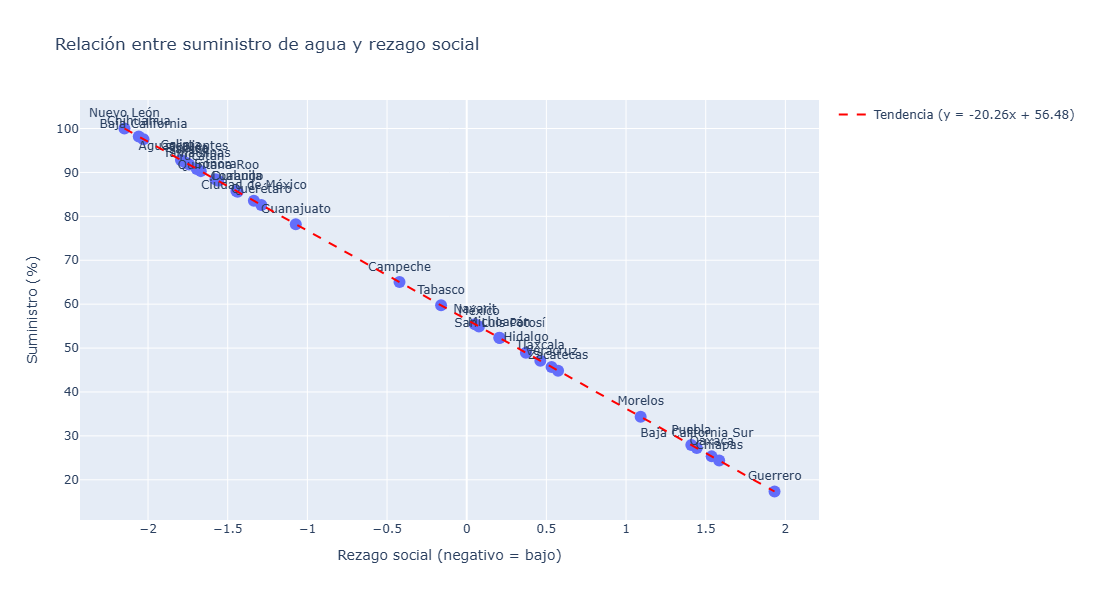

In [85]:
fig = px.scatter(suministro_vs_rezagoSocial, x='Índice de rezago social', y='Porcentaje de suministro diario',
                 text='Entidad', hover_name='Entidad',
                 title='Relación entre suministro de agua y rezago social',
                 labels={'Índice de rezago social': 'Rezago social (negativo = bajo)',
                         'Porcentaje de suministro diario': 'Suministro (%)'},
                 width=900, height=600)
fig.update_traces(textposition='top center', marker=dict(size=12))

X = suministro_vs_rezagoSocial[['Índice de rezago social']].values
y = suministro_vs_rezagoSocial['Porcentaje de suministro diario'].values
model = LinearRegression()
model.fit(X, y)
x_line = np.linspace(X.min(), X.max(), 100)
y_line = model.predict(x_line.reshape(-1, 1))

fig.add_trace(go.Scatter(x=x_line, y=y_line, mode='lines',
                         name=f'Tendencia (y = {model.coef_[0]:.2f}x + {model.intercept_:.2f})',
                         line=dict(color='red', dash='dash')))
fig.show()